# 2.5. Regresión Ridge Kernel

## Setup

In [ ]:
import math
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
import random
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.figure_factory as ff
import session_info
from scipy import stats
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn import set_config
from sklearn.datasets import make_classification
from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import (mean_absolute_error,r2_score, mean_squared_error)
from sklearn.model_selection import (train_test_split, RepeatedKFold, RepeatedStratifiedKFold, 
                                     cross_validate, cross_val_score, KFold)
from sklearn.inspection import permutation_importance
import shap

# Configuraciones
sns.set_style('dark')
pio.templates.default = "plotly_dark"
set_config(transform_output="pandas")
set_config(display='diagram')
warnings.filterwarnings("ignore")

# Magic Commands
%matplotlib inline

# Directorio de datos
dir_data = '../03_Data/'

random.seed(333)

In [4]:
def get_cv_scores_report(estimator, X, y, n_splits):
    cv_scores = cross_validate(
                    estimator = estimator,
                    X         = X,
                    y         = y,
                    scoring   = ('r2', 'neg_root_mean_squared_error'),
                    cv        = RepeatedKFold(n_splits=n_splits, n_repeats=5, random_state=333),
                )


    # Se convierte el diccionario a dataframe para facilitar la visualización
    cv_scores = pd.DataFrame(cv_scores)
    print(f"R2 en CV: mean {cv_scores.test_r2.mean():.2f}, std {cv_scores.test_r2.std():.2f}")
    print(f"RMSE en CV: mean {-cv_scores.test_neg_root_mean_squared_error.median():.2f}, std {cv_scores.test_neg_root_mean_squared_error.std():.2f}")
def rmse(model, X, y):
    predictions = model.predict(X)
    return -mean_squared_error(y, predictions, squared=False)


In [5]:
session_info.show()

## 2.5.0. Regresión Kernel Ridge

### Contexto

Recordamos que, para la regresión Ridge buscabamos minimizar la función de coste:

 $$ J(\beta) = ||X\beta - y||_2^2 + \lambda ||\beta||_2^2  $$

Aquí:
- $X$ es la matriz de características.
- $y$ es el vector de valores objetivos.
- $\beta$ es el vector de parámetros a aprender.
- $\lambda$ es el parámetro de regularización.

Para extender la Regresión de Ridge al caso no lineal, se aplica el truco del kernel. En lugar de trabajar directamente con las características originales $X$, se mapean a un espacio de características de mayor dimensión usando una función de kernel $\phi: \mathbb{R}^n \rightarrow \mathbb{R}^m$, de tal manera que:

 $$ J(\beta) = ||\phi(X)\beta - y||_2^2 + \lambda ||\beta||_2^2  $$


El "truco" del kernel permite operar en el espacio de características mapeado sin necesidad de calcular explícitamente las nuevas características. En vez de eso, se calcula el producto escalar de las imágenes de las características mediante una función de kernel $K$:

 $$ K(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle  $$

 Por lo tanto, con el truco del kernel, la función de costo de Kernel Ridge Regression se convierte en:

 $$ J(\beta) = ||K\beta - y||_2^2 + \lambda ||\beta||_2^2  $$

Aquí, $K$ es la matriz del kernel, donde cada entrada $K_{ij}$ es el valor del kernel evaluado en los puntos de datos $x_i$ y $x_j$.

Como en KRR, no trabajamos directamente con $\beta$ en el espacio de características original, sino con $\mathbf{\alpha}$ en el espacio de características mapeado. La solución analítica para KRR es:

**Problema primal**
$$ \beta = (X^T X + \lambda I)^{-1} X^T y = (\sum_{i=1}^{N} x_i x_i^T + \lambda I)^{-1} X^T y $$

**Problema dual**
$$ \beta = X^T (X X^T + \lambda I_N)^{-1} y $$
$$ \mathbf{\alpha} = (\mathbf{K} + \lambda \mathbf{I})^{-1} \mathbf{y} $$

Donde:
- $\mathbf{K}$ es la matriz del kernel, con $\mathbf{K}_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$ siendo $k$ la función del kernel.

Una vez obtenido $\mathbf{\alpha}$, para hacer una predicción para una nueva entrada $\mathbf{x}_{\text{new}}$, se utiliza:

$$ \hat{f}(X) = \beta^T X = \sum_{i=1}^{N} \alpha_i X_i^T X $$
$$ y_{\text{pred}}(\mathbf{x}_{\text{new}}) = \sum_{i=1}^{N} \alpha_i k(\mathbf{x}_i, \mathbf{x}_{\text{new}}) $$

**Ejemplo de kernel polinomial:** 

Consideremos un espacio de entrada simple $\mathbb{R}$ y un kernel polinomial de grado 2. Supongamos:

$$ K(x_i, x_j) = (x_i \cdot x_j + c)^2 $$

Desarrollando el cuadrado, obtenemos:

$$ K(x_i, x_j) = x_i^2 x_j^2 + 2c x_i x_j + c^2 $$

Si consideramos una transformación $\phi(x) = [x^2, \sqrt{2c} x, c]$, entonces el producto escalar en el espacio transformado es:

$$ \langle \phi(x_i), \phi(x_j) \rangle = x_i^2 x_j^2 + 2c x_i x_j + c^2 $$

Como puedes ver, este producto escalar es exactamente igual a nuestro kernel polinomial. Es decir, sin haber transformado explícitamente los datos con $\phi$, el kernel nos dio el producto escalar como si lo hubiéramos hecho.

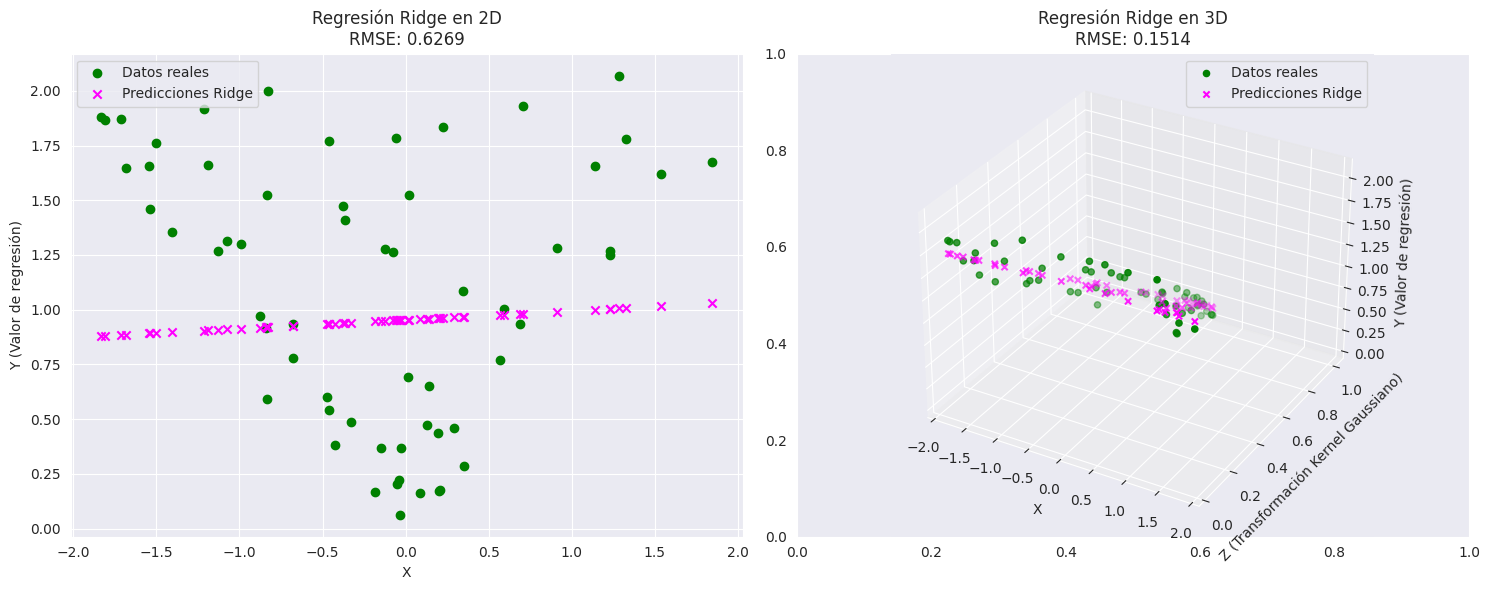

In [6]:
# Generación de puntos X y
# ----------------------------------------------------------------------------------------
N = 100
theta = 2 * np.pi * np.random.rand(N)
r = np.random.rand(N)
x_circle = r * np.cos(theta)
y_circle = r * np.sin(theta)
theta = 2 * np.pi * np.random.rand(N)
r = 1 + np.random.rand(N)
x_ring = r * np.cos(theta)
y_ring = r * np.sin(theta)

# Generar un valor de regresión basado en la distancia al origen más ruido
y_circle = np.sqrt(x_circle**2 + y_circle**2) + 0.1 * np.random.randn(N)
y_ring = np.sqrt(x_ring**2 + y_ring**2) + 0.1 * np.random.randn(N)

# Combinar datos
X = np.hstack([x_circle, x_ring]).reshape(-1, 1)
Y = np.hstack([y_circle, y_ring]).reshape(-1, 1)
# ----------------------------------------------------------------------------------------
# Modelación 2D
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=33)

ridge_2D = Ridge(alpha=1.0)
ridge_2D.fit(X_train, Y_train)
Y_pred_2D = ridge_2D.predict(X_test)
rmse_2D = np.sqrt(mean_squared_error(Y_test, Y_pred_2D))

# ----------------------------------------------------------------------------------------
# Modelación 3D

# Transformar los datos de entrenamiento y prueba usando el kernel gaussiano
Z_train = np.exp(-0.5 * (X_train**2 + Y_train**2))
Z_test = np.exp(-0.5 * (X_test**2 + Y_test**2))
X_train_3D = np.hstack([X_train, Z_train])
X_test_3D = np.hstack([X_test, Z_test])

ridge_3D = Ridge(alpha=1.0)
ridge_3D.fit(X_train_3D, Y_train)
Y_pred_3D = ridge_3D.predict(X_test_3D)
rmse_3D = np.sqrt(mean_squared_error(Y_test, Y_pred_3D))

# ----------------------------------------------------------------------------------------
# Visualizar los datos y las predicciones
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(X_test, Y_test, color='green', label='Datos reales')
axes[0].scatter(X_test, Y_pred_2D, color='magenta', marker='x', label='Predicciones Ridge')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y (Valor de regresión)')
axes[0].set_title('Regresión Ridge en 2D\nRMSE: {:.4f}'.format(rmse_2D))
axes[0].legend()
axes[0].grid(True)

ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.scatter(X_test, Z_test, Y_test, color='green', label='Datos reales')
ax.scatter(X_test, Z_test, Y_pred_3D, color='magenta', marker='x', label='Predicciones Ridge')
ax.set_xlabel('X')
ax.set_ylabel('Z (Transformación Kernel Gaussiano)')
ax.set_zlabel('Y (Valor de regresión)')
ax.set_title('Regresión Ridge en 3D\nRMSE: {:.4f}'.format(rmse_3D))
ax.legend()

plt.tight_layout()
plt.show()

1. **Kernel Lineal**:
$$ K(x, x') = x \cdot x' $$

1. **Kernel Polinómico**:
$$ K(x, x') = (x \cdot x' + c)^d $$
   - $ c $ es un coeficiente libre (definido por el usuario), típicamente $ c = 1 $.
   - $ d $ es el grado del polinomio.

1. **Kernel Gaussiano o RBF (Radial Basis Function)**:
$$ K(x, x') = \exp\left(-\gamma ||x - x'||^2 \right) $$
   - $ \gamma $ es el parámetro del kernel, típicamente $ \gamma = \frac{1}{2\sigma^2} $.

1. **Kernel Sigmoidal**:
$$ K(x, x') = \tanh(\alpha x \cdot x' + c) $$
   - $ \alpha $ es el parámetro de escala.
   - $ c $ es el coeficiente libre.

1. **Kernel Laplaciano**:
$$ K(x, x') = \exp\left(-\gamma ||x - x'||_1 \right) $$
   - $ \gamma $ es el parámetro del kernel.
   - $ ||.||_1 $ denota la norma $ L_1 $ (la suma de las diferencias absolutas de las componentes).

### Ejemplo

**Boston Housing**

El conjunto de datos de Boston Housing contiene información recolectada por el Servicio de Censos de los EE.UU. respecto a la vivienda en el área de Boston Mass. Es ampliamente utilizado para tareas de aprendizaje supervisado y es muy conocido en el campo de la aprendizaje automático.Contiene 506 registros, cada uno con 13 atributos numéricos y 1 atributo de objetivo (medv), que denota el valor medio de las viviendas ocupadas por sus propietarios en miles de dólares. El objetivo primordial suele sera predecir el valor medio de las viviendas en un área específica, dado un conjunto de atributos.

| Característica | Descripción                                                                 |
|----------------|-----------------------------------------------------------------------------|
| crim           | Tasa de criminalidad per cápita por ciudad                                  |
| zn             | Proporción de terreno residencial zonificado para lotes de más de 25,000 pies cuadrados |
| indus          | Proporción de acres de negocios no minoristas por ciudad                     |
| chas           | Variable ficticia Charles River (1 si el tramo limita con el río; 0 en caso contrario) |
| nox            | Concentración de óxidos nítricos (partes por 10 millones)                    |
| rm             | Número medio de habitaciones por vivienda                                   |
| age            | Proporción de unidades ocupadas por sus propietarios construidas antes de 1940 |
| dis            | Distancias ponderadas a cinco centros de empleo de Boston                   |
| rad            | Índice de accesibilidad a carreteras radiales                                |
| tax            | Tasa de impuesto a la propiedad de valor total por $10,000                  |
| ptratio        | Relación alumno-profesor por ciudad                                         |
| black          | 1000(Bk - 0.63)^2 donde Bk es la proporción de personas de color por ciudad  |
| lstat          | % menor estado de la población                                              |
| medv           | Valor medio de viviendas ocupadas por sus propietarios en $1000's           |


In [7]:
df = pd.read_csv(dir_data + 'boston.csv')

In [8]:
# Se elimina el sesgo social
df.drop(['black'],axis='columns',inplace=True)

In [9]:
# Configuración de los datos
vcontinua = df.drop(['chas','medv'],axis=1).columns.to_list()
vcategorica = ['chas']
target = ['medv']

X = df[vcontinua + vcategorica]
y = df[target]

In [10]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=333, shuffle=True)

Los hiperparámetros principales en KRR son:

1. **alpha (o λ)**: Es el parámetro de regularización.

2. **Kernel**: Es la función que transforma el espacio de entrada en otro espacio de características.
   
3. **gamma**: Es el parámetro del kernel para 'rbf', 'poly' y 'sigmoid'.
   - Si gamma es 'scale' (por defecto), entonces se calcula como $ \frac{1}{{n \times X.var()}} $ para las características de X.
   - Si es 'auto', usa $ \frac{1}{n} $.

4. **degree (para kernel polinomial)**: Es el grado del polinomio.

5. **coef0 (para kernel polinomial y sigmoid)**: Término independiente en la función del kernel.

In [11]:
def objective(space):
    model = make_pipeline(
        StandardScaler(),
        KernelRidge(alpha=space['alpha'], 
                        kernel=space['kernel'], 
                        gamma=space['gamma'], 
                        degree=space['degree'], 
                        coef0=space['coef0']))
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    return {'loss': mse, 'status': STATUS_OK}

# Espacio hiperparametral
space = {
    'alpha': hp.loguniform('alpha', -5, 5),
    'kernel': hp.choice('kernel', ['linear', 'poly', 'rbf', 'sigmoid']),
    'gamma': hp.loguniform('gamma', -5, 5),
    'degree': hp.choice('degree', [2, 3, 4, 5]),
    'coef0': hp.uniform('coef0', -1, 1)
}

trials = Trials()
best = fmin(fn=objective, 
            space=space, 
            algo=tpe.suggest, 
            max_evals=100, 
            trials=trials)

  2%|▏         | 2/100 [00:00<00:31,  3.12trial/s, best loss: 48.747806707945244]

100%|██████████| 100/100 [00:29<00:00,  3.38trial/s, best loss: 8.961771168182173]


In [12]:
best_kernel = ['linear', 'poly', 'rbf', 'sigmoid'][best['kernel']]

# Mejor modelo utilizando Hyperopt
krr = make_pipeline(
        StandardScaler(),
        KernelRidge(alpha=best['alpha'], 
                        kernel=best_kernel, 
                        gamma=best['gamma'], 
                        degree=best['degree'], 
                        coef0=best['coef0']))

# Entrenar el modelo con los mejores hiperparámetros
krr.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kernelridge',
                 KernelRidge(alpha=0.026177561437962467,
                             coef0=0.43408130685037005, degree=1,
                             gamma=0.04458829576042064, kernel='rbf'))])

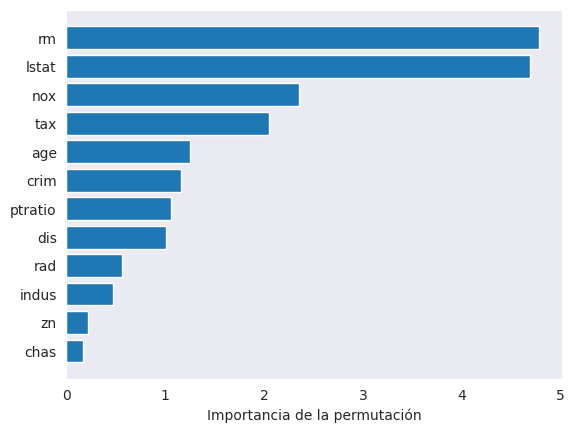

In [13]:
# Obtener importancias de las características usando importancia de permutación
pi = permutation_importance(krr, X_test, y_test, n_repeats=20, scoring=rmse,random_state=333)

# Visualizar las importancias
sorted_idx = pi.importances_mean.argsort()

plt.barh(range(X.shape[1]), pi.importances_mean[sorted_idx])
plt.yticks(range(X.shape[1]),[krr.feature_names_in_[i] for i in sorted_idx])
plt.xlabel("Importancia de la permutación")
plt.show()

In [14]:
print("Kernel Ridge Regression:")
get_cv_scores_report(krr,X_test,y_test,10)

Kernel Ridge Regression:


R2 en CV: mean 0.85, std 0.10
RMSE en CV: mean 2.80, std 1.11


In [15]:
print("Gradiente Estocástico Descendente:")
print("R2 en CV: mean 0.62, std 0.23")
print("RMSE en CV: mean 4.09, std 1.49")

Gradiente Estocástico Descendente:
R2 en CV: mean 0.62, std 0.23
RMSE en CV: mean 4.09, std 1.49


In [23]:
background_data = shap.sample(X_train, 50)
explainer = shap.KernelExplainer(krr_predict, background_data)

def krr_predict(data):
    return krr.predict(data)

explainer = shap.KernelExplainer(krr_predict, background_data)
shap_values = explainer.shap_values(X_test)

  0%|          | 0/152 [00:00<?, ?it/s]

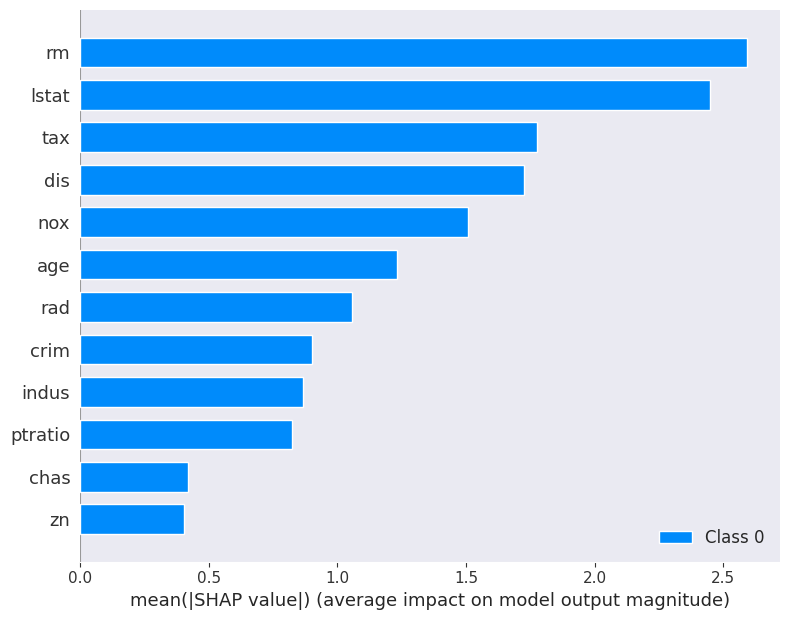

In [24]:
shap.summary_plot(shap_values, X_test)